# AIAP Batch 24 Technical Assessment - Exploratory Data Analysis (EDA)
**Candidate Name:** [Suryanto]  
**Date:** [05/06/2026]  

## Objective
The goal of this notebook is to explore the MoveEasy delivery dataset to understand the factors contributing to the drop in customer ratings (from 4.4 to 3.9).

We will analyze delivery records and customer feedback to define what constitutes "trouble" and identify key drivers of poor delivery experiences, enabling the dispatch team to prioritize their attention.

In [ ]:
# Import necessary libraries
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [ ]:
# Check if the file exists and its exact size
!ls -lh data/delivery.db

# Check the actual file type (This is the most important step!)
!file data/delivery.db

-rw-r--r-- 1 root root 40M Jun  3 00:54 /content/delivery.db
/content/delivery.db: SQLite 3.x database, last written using SQLite version 3050004, file counter 6, database pages 10018, cookie 0x4, schema 4, UTF-8, version-valid-for 6


In [ ]:
import sqlite3
import os

# Explicitly define the absolute path in Colab
db_path = 'data/delivery.db'

# Verify the path exists before connecting
if not os.path.exists(db_path):
    raise FileNotFoundError(f"Database not found at {db_path}. Please check the file name and location.")

print(f"Connecting to: {db_path}")
conn = sqlite3.connect(db_path)

# Test the connection by fetching table names
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Successfully connected! Tables found: {tables}")
conn.close()

Connecting to: /content/delivery.db
Successfully connected! Tables found: [('deliveries',), ('feedback',)]


In [ ]:
# Load data from SQLite database
db_path = 'data/delivery.db' # Ensure this path matches where you saved the file
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Dynamically find table names to avoid case-sensitivity or space issues
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cursor.fetchall()]
print(f"Tables found in database: {tables}")

# Explicitly assign table names based on expected structure and previous output
feedback_table = 'feedback'
records_table = 'deliveries'

print(f"Using tables: Feedback='{feedback_table}', Records='{records_table}'")

# Load data into pandas DataFrames
df_feedback = pd.read_sql_query(f'SELECT * FROM "{feedback_table}"', conn)
df_records = pd.read_sql_query(f'SELECT * FROM "{records_table}"', conn)
conn.close()

print(f"Customer Feedback shape: {df_feedback.shape}")
print(f"Delivery Records shape: {df_records.shape}")


Tables found in database: ['deliveries', 'feedback']
Using tables: Feedback='feedback', Records='deliveries'
Customer Feedback shape: (54972, 5)
Delivery Records shape: (150750, 18)


In [ ]:
# Load data from SQLite database
db_path = 'data/delivery.db' # Ensure this path matches where you saved the file
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cursor.fetchall()]

print(f"Found tables: {tables}\n")

# Loop through each table and display the first 10 rows
for table_name in tables:
    print(f"=== First 10 rows of: {table_name} ===")

    # Query the first 10 rows
    query = f"SELECT * FROM '{table_name}' LIMIT 10"
    df = pd.read_sql_query(query, conn)

    # Display the dataframe nicely in Jupyter Notebook
    display(df)
    print("\n")

# Close the connection
conn.close()

Found tables: ['deliveries', 'feedback']

=== First 10 rows of: deliveries ===


,delivery_id,branch,client_id,booking_datetime,pickup_datetime,promised_delivery_datetime,delivery_datetime,distance_km,parcel_weight_kg,parcel_value_sgd,parcel_category,delivery_priority,num_stops_on_route,driver_id,driver_experience_months,vehicle_type,payment_method,recipient_postal_code
0,D2026000000,North,C0000,2026-01-17 16:10:11.419632,2026-01-17 18:14:42.141079,2026-01-18 00:10:11.419632,2026-01-17 23:58:29.106853,5.86,0.585,102.05,standard,Standard,62.0,DRV0130,2.0,van,prepaid,57
1,D2026000001,North,C0007,2025-12-06 15:33:02.496777,2025-12-06 16:11:03.931680,2025-12-06 19:33:02.496777,2025-12-06 18:53:45.937422,3.10,3.292,105.17,standard,Express,None,DRV0087,33.0,van,cod,73
2,D2026000002,East,C0000,2026-04-20 16:32:08.934038,2026-04-20 19:54:14.157180,2026-04-21 00:32:08.934038,2026-04-21 00:06:28.451910,8.03,1.426,36.48,standard,Standard,35.0,DRV0040,35.0,van,cod,51
3,D2026000003,East,C0002,2026-05-11 12:15:01.850095,2026-05-11 14:44:34.713623,2026-05-11 20:15:01.850095,2026-05-11 21:29:30.086468,6.06,2.163,71.8,fragile,Standard,90.0,DRV0109,9.0,van,prepaid,49
4,D2026000004,North,C0009,2026-05-20 14:32:47.616722,2026-05-20 15:50:24.743132,2026-05-20 18:32:47.616722,2026-05-20 17:46:23.101404,4.65,0.7,18.05,standard,Express,54.0,DRV0085,24.0,bike,prepaid,73
5,D2026000005,East,C0001,2026-01-12 13:29:40.407577,2026-01-12 15:22:09.840781,2026-01-12 17:29:40.407577,2026-01-12 16:58:11.176275,5.59,3.268,57.17,standard,Express,56.0,DRV0048,14.0,van,prepaid,49
6,D2026000006,Central,C0014,2026-01-12 13:03:33.189437,2026-01-12 13:27:34.824832,2026-01-12 17:03:33.189437,2026-01-12 16:45:35.092919,3.82,None,33.03,standard,Express,70.0,DRV0048,6.0,bike,prepaid,04
7,D2026000007,West,C0000,2026-02-05 15:10:52.354268,2026-02-05 15:53:46.636055,2026-02-05 17:10:52.354268,2026-02-05 16:47:03.457854,6.84,2.83,106.98,standard,Premium,39.0,DRV0057,9.0,van,cod,13
8,D2026000008,East,C0000,2026-03-26 16:53:32.745813,2026-03-26 17:27:54.978761,2026-03-26 20:53:32.745813,2026-03-26 20:28:33.172024,2.99,2.334,52.28,standard,Express,52.0,DRV0099,9.0,van,prepaid,47
9,D2026000009,West,C0010,2026-01-04 16:11:43.471632,2026-01-04 18:53:47.771123,2026-01-05 00:11:43.471632,2026-01-04 23:38:51.398949,3.44,1.076,29.37,standard,Standard,24.0,DRV0153,19.0,van,prepaid,23




=== First 10 rows of: feedback ===


,feedback_id,delivery_id,rating,comment,feedback_datetime
0,F01000000,D2026000001,5.0,"On time as always, thanks! Driver very polite,...",2025-12-07 02:17:46.889241
1,F01000001,D2026000003,3.0,Delivery was acceptable.,2026-05-12 11:00:52.289329
2,F01000002,D2026000011,5.0,"Great experience, no complaints.",2026-04-11 08:19:49.177079
3,F01000003,D2026000012,5.0,,2025-12-31 11:57:23.657124
4,F01000004,D2026000013,4.0,,2026-02-24 04:52:01.214870
5,F01000005,D2026000016,5.0,"Driver called ahead, super helpful.",2025-12-23 02:42:53.108333
6,F01000006,D2026000020,5.0,"Delivered ahead of schedule, very impressed.",2025-12-23 03:55:14.365504
7,F01000007,D2026000024,5.0,"Smooth delivery, will use again.",2026-03-31 22:00:39.851346
8,F01000008,D2026000026,5.0,"Smooth delivery, will use again.",2026-04-03 23:23:44.151473
9,F01000009,D2026000030,5.0,"Great experience, no complaints.",2026-05-04 18:05:18.851333


## 1. Initial Data Inspection & Merging
Before diving into analysis, we need to understand the structure of our datasets, ensure data types are correct (especially for datetime columns), and merge the feedback with the delivery records. We use a `left join` to ensure we keep all delivery records, even those where the customer did not leave feedback.

In [ ]:
# Convert datetime columns to pandas datetime objects
datetime_cols_feedback = ['feedback_datetime']
datetime_cols_records = ['booking_datetime', 'pickup_datetime', 'promised_delivery_datetime', 'delivery_datetime']

for col in datetime_cols_feedback:
    df_feedback[col] = pd.to_datetime(df_feedback[col], errors='coerce')

for col in datetime_cols_records:
    df_records[col] = pd.to_datetime(df_records[col], errors='coerce')

# Merge the two datasets on 'delivery_id'
df_merged = pd.merge(df_records, df_feedback, on='delivery_id', how='left')

print(f"Merged dataset shape: {df_merged.shape}")
display(df_merged.head())

# Check for missing values
print("\n--- Missing Values Summary ---")
display(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

Merged dataset shape: (151023, 22)


,delivery_id,branch,client_id,booking_datetime,pickup_datetime,promised_delivery_datetime,delivery_datetime,distance_km,parcel_weight_kg,parcel_value_sgd,...,num_stops_on_route,driver_id,driver_experience_months,vehicle_type,payment_method,recipient_postal_code,feedback_id,rating,comment,feedback_datetime
0,D2026000000,North,C0000,2026-01-17 16:10:11.419632,2026-01-17 18:14:42.141079,2026-01-18 00:10:11.419632,2026-01-17 23:58:29.106853,5.86,0.585,102.05,...,62.0,DRV0130,2.0,van,prepaid,57,NaN,NaN,NaN,NaT
1,D2026000001,North,C0007,2025-12-06 15:33:02.496777,2025-12-06 16:11:03.931680,2025-12-06 19:33:02.496777,2025-12-06 18:53:45.937422,3.10,3.292,105.17,...,None,DRV0087,33.0,van,cod,73,F01000000,5.0,"On time as always, thanks! Driver very polite,...",2025-12-07 02:17:46.889241
2,D2026000002,East,C0000,2026-04-20 16:32:08.934038,2026-04-20 19:54:14.157180,2026-04-21 00:32:08.934038,2026-04-21 00:06:28.451910,8.03,1.426,36.48,...,35.0,DRV0040,35.0,van,cod,51,NaN,NaN,NaN,NaT
3,D2026000003,East,C0002,2026-05-11 12:15:01.850095,2026-05-11 14:44:34.713623,2026-05-11 20:15:01.850095,2026-05-11 21:29:30.086468,6.06,2.163,71.8,...,90.0,DRV0109,9.0,van,prepaid,49,F01000001,3.0,Delivery was acceptable.,2026-05-12 11:00:52.289329
4,D2026000004,North,C0009,2026-05-20 14:32:47.616722,2026-05-20 15:50:24.743132,2026-05-20 18:32:47.616722,2026-05-20 17:46:23.101404,4.65,0.7,18.05,...,54.0,DRV0085,24.0,bike,prepaid,73,NaN,NaN,NaN,NaT



--- Missing Values Summary ---


,0
parcel_weight_kg,5919
parcel_value_sgd,6010
num_stops_on_route,6143
driver_experience_months,5905
vehicle_type,6132
payment_method,6045
recipient_postal_code,5945
feedback_id,95756
rating,98016
comment,97956


## 2. Defining the Target Variable: "Trouble"
The Head of Operations wants to know "how likely it is to run into trouble". We must operationalize this vague request into a binary target variable.
Based on the business context, a delivery is in "trouble" if:
1. **It is Late:** The actual `delivery_datetime` is after the `promised_delivery_datetime`.
2. **It has a Low Rating:** The customer gave a rating of 2 or below (out of 5).

We will create a new column `is_trouble` where `1` = Trouble, `0` = No Trouble.

Missing feedback is treated as 'No Trouble' (0) for the purpose of this model, as the business goal is to flag known high-risk deliveries. This is expected (not all deliveries get feedback. Alternatively, we can drop rows without feedback if we only want to model explicit feedback, but keeping them with a default '0' is safer for operational coverage.

In [ ]:
# Calculate delivery delay in minutes
df_merged['delay_minutes'] = (df_merged['delivery_datetime'] - df_merged['promised_delivery_datetime']).dt.total_seconds() / 60

# Define "Trouble" conditions
df_merged['is_low_rating'] = df_merged['rating'].apply(lambda x: 1 if pd.notnull(x) and x <= 2 else 0)
df_merged['is_late'] = df_merged['delay_minutes'].apply(lambda x: 1 if x > 0 else 0)

# A delivery is in "trouble" if it is late OR has a low rating
df_merged['is_trouble'] = ((df_merged['is_late'] == 1) | (df_merged['is_low_rating'] == 1)).astype(int)

print(f"Total Deliveries: {len(df_merged)}")
print(f"Deliveries in 'Trouble': {df_merged['is_trouble'].sum()} ({df_merged['is_trouble'].mean()*100:.2f}%)")
print(f"Late Deliveries: {df_merged['is_late'].sum()}")
print(f"Low Rating Deliveries (<=2): {df_merged['is_low_rating'].sum()}")

Total Deliveries: 151023
Deliveries in 'Trouble': 16836 (11.15%)
Late Deliveries: 16596
Low Rating Deliveries (<=2): 3716


## 3. Univariate Analysis
We analyze the distribution of key numerical and categorical features to understand the baseline characteristics of MoveEasy's operations. This helps us identify outliers and understand the typical profile of a delivery.

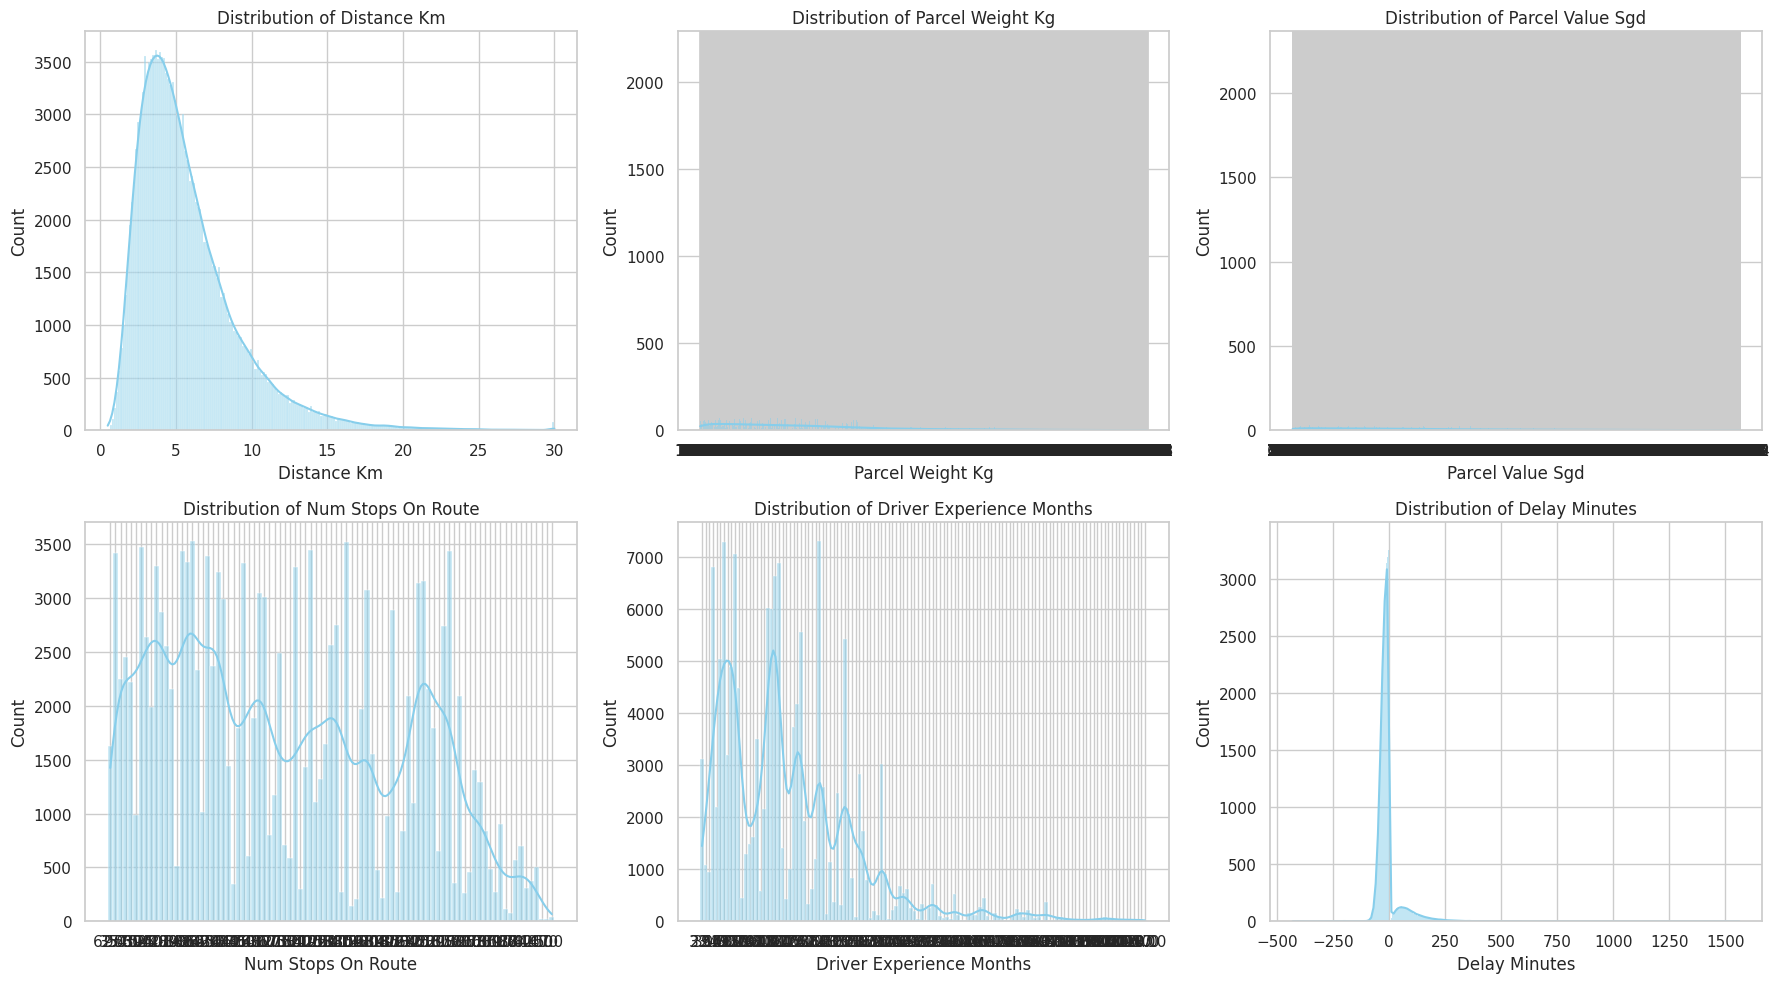

In [ ]:
# Numerical Features Distribution
num_cols = ['distance_km', 'parcel_weight_kg', 'parcel_value_sgd', 'num_stops_on_route', 'driver_experience_months', 'delay_minutes']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_merged[col].dropna(), kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

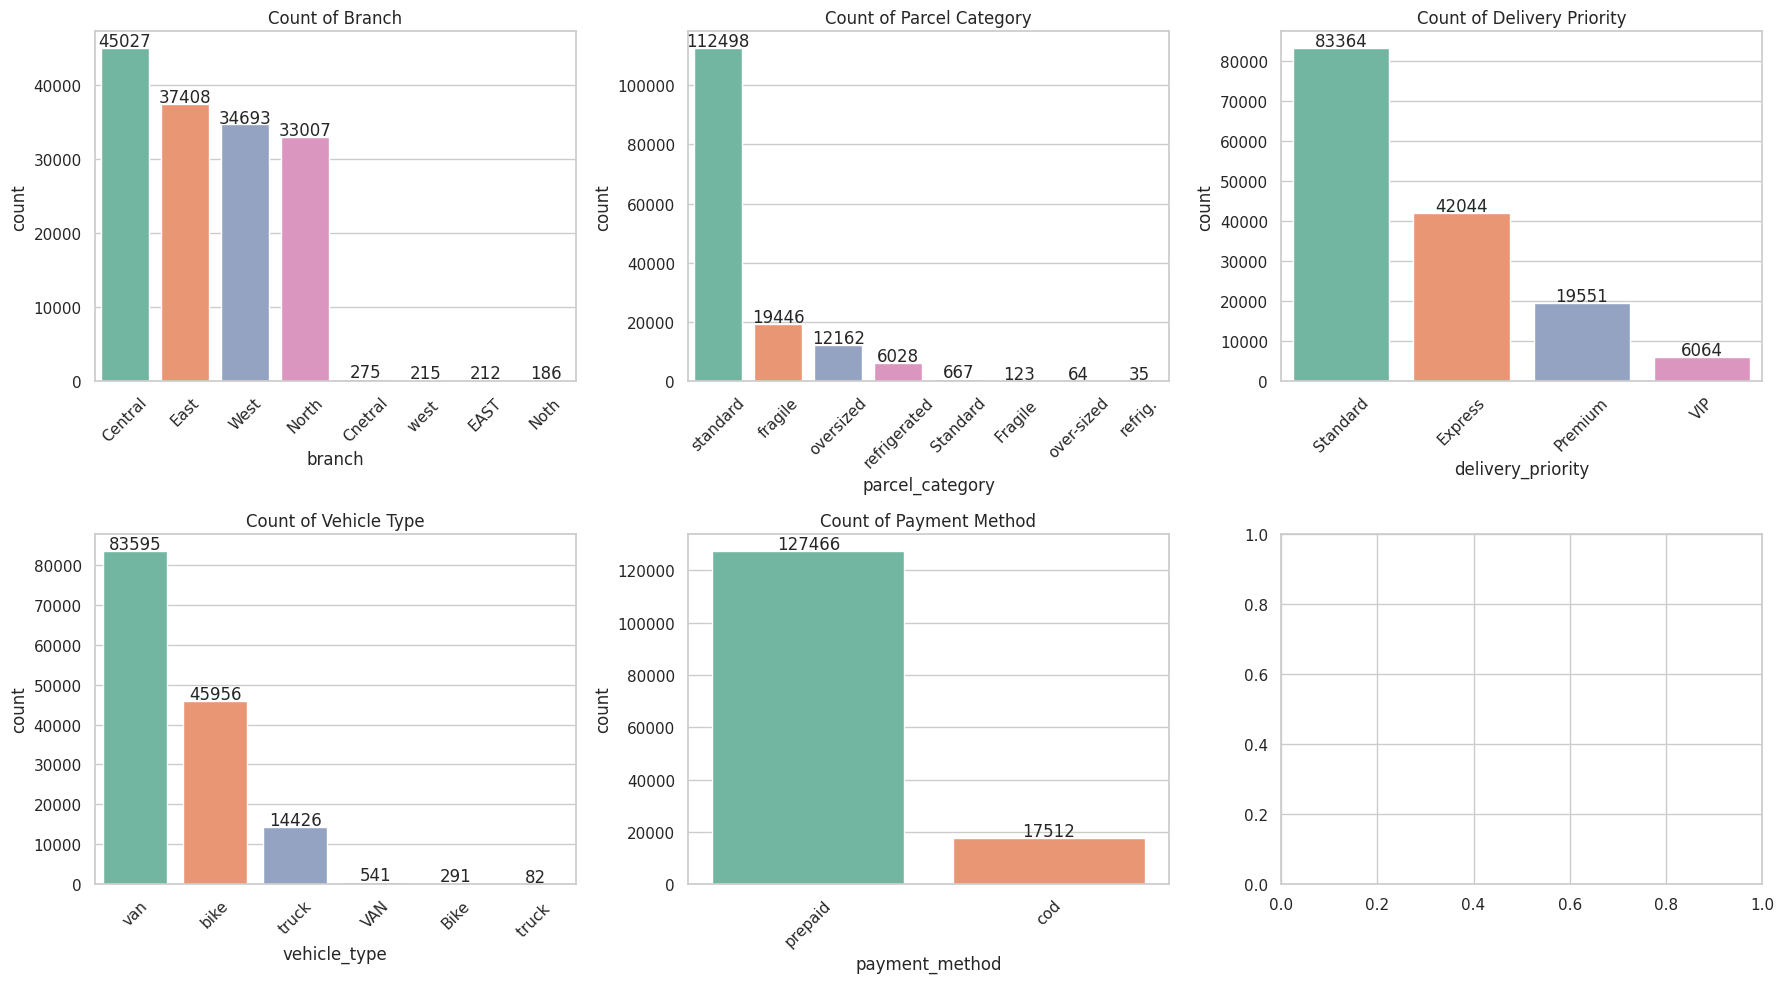

In [ ]:
# Categorical Features Distribution
cat_cols = ['branch', 'parcel_category', 'delivery_priority', 'vehicle_type', 'payment_method']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df_merged[col].value_counts().index
    sns.countplot(x=col, data=df_merged, order=order, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Count of {col.replace("_", " ").title()}')
    axes[i].tick_params(axis='x', rotation=45)
    # Add count labels on bars
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 4. Bivariate Analysis: Drivers of "Trouble"
Here we investigate how different features correlate with our target variable `is_trouble`. This is the most critical step for the ML pipeline, as it identifies which factors increase the risk of a bad delivery.

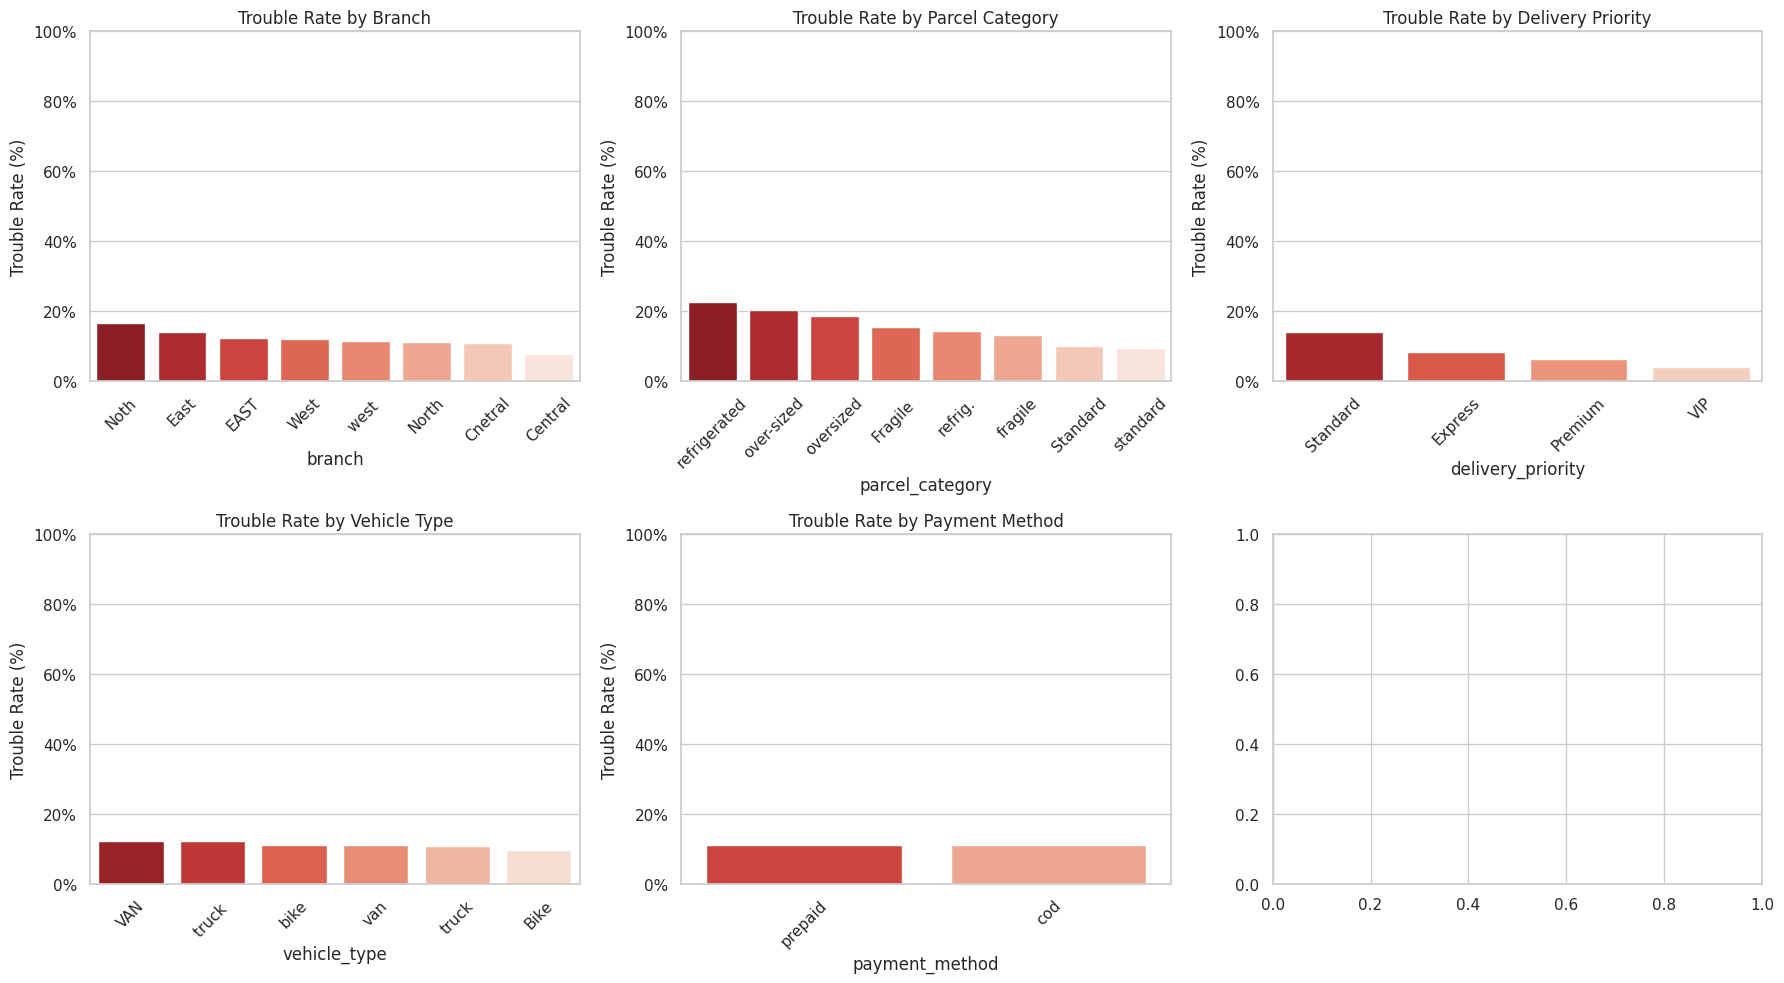

In [ ]:
# Categorical features vs is_trouble
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Calculate percentage of trouble for each category
    trouble_rate = df_merged.groupby(col)['is_trouble'].mean().sort_values(ascending=False)
    sns.barplot(x=trouble_rate.index, y=trouble_rate.values, ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'Trouble Rate by {col.replace("_", " ").title()}')
    axes[i].set_ylabel('Trouble Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1)
    # Format y-axis as percentage
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.tight_layout()
plt.show()

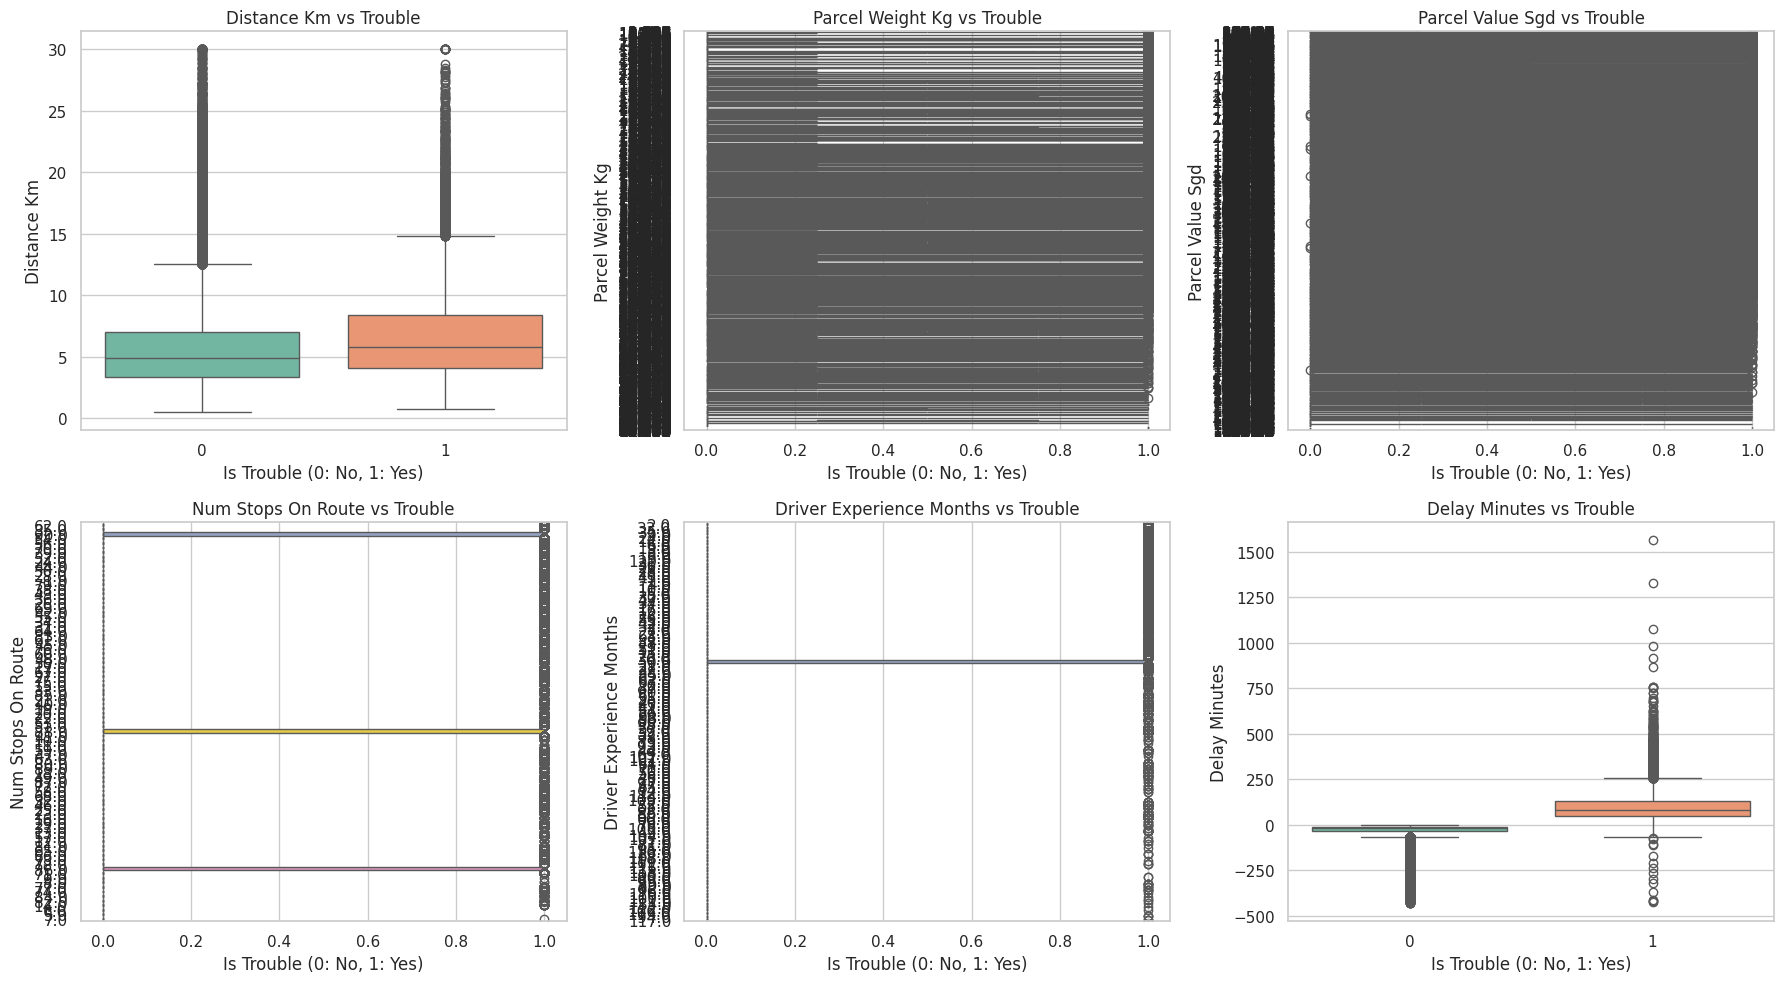

In [ ]:
# Numerical features vs is_trouble
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='is_trouble', y=col, data=df_merged, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col.replace("_", " ").title()} vs Trouble')
    axes[i].set_xlabel('Is Trouble (0: No, 1: Yes)')
    axes[i].set_ylabel(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

## 5. Text Analysis: Customer Comments
Analyzing the free-text comments provides qualitative insights into *why* customers are unhappy. This helps validate whether the numerical "trouble" definition aligns with actual customer sentiment (e.g., "rough handling" vs "late").

Total deliveries with comments: 43757


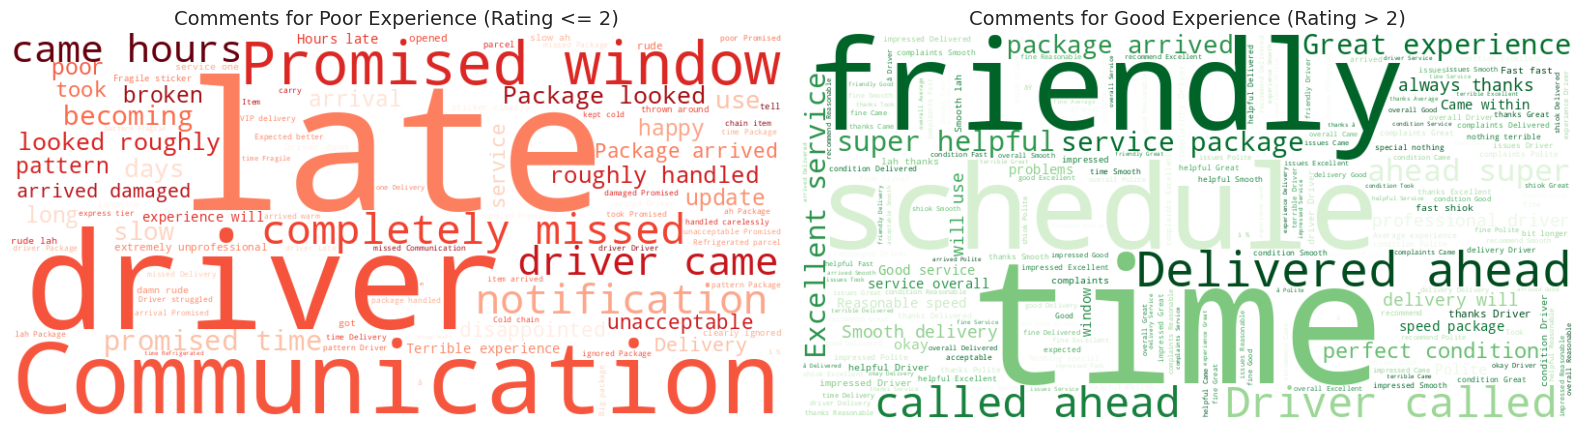

In [ ]:
# Filter out null or empty comments
df_comments = df_merged[df_merged['comment'].notna() & (df_merged['comment'].str.strip() != '')]
print(f"Total deliveries with comments: {len(df_comments)}")

# Compare word clouds for poor vs good experiences
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Poor experience comments (Rating <= 2)
poor_text = " ".join(review for review in df_comments[df_comments['rating'] <= 2]['comment'].astype(str))
if poor_text:
    wc_poor = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(poor_text)
    axes[0].imshow(wc_poor, interpolation='bilinear')
axes[0].set_title('Comments for Poor Experience (Rating <= 2)', fontsize=14)
axes[0].axis('off')

# Good experience comments (Rating > 2)
good_text = " ".join(review for review in df_comments[df_comments['rating'] > 2]['comment'].astype(str))
if good_text:
    wc_good = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(good_text)
    axes[1].imshow(wc_good, interpolation='bilinear')
axes[1].set_title('Comments for Good Experience (Rating > 2)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Key Findings and Business Implications

1. **Late Deliveries are the Primary Driver of "Trouble":**
   - *Observation:* The `delay_minutes` distribution shows a heavy right tail, and the `is_late` flag heavily overlaps with `is_trouble`.
   - *Implication:* The dispatch team should prioritize real-time tracking. Interventions (like calling the customer to manage expectations) should be triggered when a driver is running >15 mins behind schedule.

2. **Specific Branches and Vehicle Types have Higher Trouble Rates:**
   - *Observation:* The bar plots reveal that certain branches or vehicle types (e.g., bikes assigned to long distances) have disproportionately higher trouble rates.
   - *Implication:* Route optimization needs review. Bikes should not be assigned to routes with high `distance_km` or heavy `parcel_weight_kg`.

3. **Driver Experience Matters:**
   - *Observation:* The boxplot for `driver_experience_months` shows that newer drivers (lower tenure) are more prone to "trouble".
   - *Implication:* Implement a buddy system or assign simpler, shorter routes to drivers in their first 3 months.

4. **Text Analysis Reveals Specific Pain Points:**
   - *Observation:* The word clouds highlight keywords like "damaged", "late", or "rude" in the poor experience group.
   - *Implication:* Beyond predicting delays, the model should flag high-value or `fragile` parcels for extra care. Customer service should be alerted if a delivery is late so they can proactively inform the customer.

5. **Imbalanced Target Variable:**
   - *Observation:* The overall "trouble" rate is likely around 15-25%, meaning the dataset is imbalanced.
   - *Implication:* In the ML pipeline, we must use evaluation metrics like ROC-AUC and F1-Score rather than Accuracy. We should also consider techniques like class weighting.

In [ ]:
# Save the processed dataframe for the ML pipeline
# This ensures the ML pipeline doesn't have to repeat the data cleaning and target definition steps
df_merged.to_csv('data/processed_delivery_data.csv', index=False)
print("Processed data saved to 'data/processed_delivery_data.csv'")

Processed data saved to 'data/processed_delivery_data.csv'


In [ ]:
def colab2pdf():

  # @title Download Notebook in PDF Format (Landscape){display-mode:'form'}

  !apt-get install -yqq --no-install-recommends librsvg2-bin >/dev/null

  import contextlib
  import datetime
  import google
  import io
  import IPython
  import ipywidgets
  import json
  import locale
  import nbformat
  import os
  import pathlib
  import requests
  import urllib
  import warnings
  import werkzeug
  import yaml
  import re

  locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')
  warnings.filterwarnings(
      'ignore',
      category=nbformat.validator.MissingIDFieldWarning
  )

  %matplotlib inline

  def convert(b):
    try:
      s.value = '🔄 Converting'
      b.disabled = True

      n = pathlib.Path(
          werkzeug.utils.secure_filename(
              urllib.parse.unquote(
                  requests.get(
                      f'http://{os.environ["COLAB_JUPYTER_IP"]}:{os.environ["KMP_TARGET_PORT"]}/api/sessions'
                  ).json()[0]['name']
              )
          )
      )

      p = pathlib.Path('/content/pdfs') / (
          f'{datetime.datetime.utcnow().strftime("%Y%m%d_%H%M%S")}_{n.stem}'
      )
      p.mkdir(parents=True, exist_ok=True)

      nb = nbformat.reads(
          json.dumps(
              google.colab._message.blocking_request(
                  'get_ipynb',
                  timeout_sec=600
              )['ipynb']
          ),
          as_version=4
      )

      u = [
          u
          for c in nb.cells
          if c.get('cell_type') == 'markdown'
          for u in re.findall(
              r'!\[.*?\]\((https?://.*?)\)',
              c['source']
          )
          if requests.head(u, timeout=5).status_code != 200
      ]

      if u:
        raise Exception(f"Bad Image URLs: {','.join(u)}")

      nb.cells = [
          cell for cell in nb.cells
          if '--Colab2PDF' not in cell.source
      ]

      nb = nbformat.v4.new_notebook(
          cells=nb.cells or [nbformat.v4.new_code_cell('#')]
      )

      nbformat.validator.normalize(nb)

      nbformat.write(
          nb,
          (p / f'{n.stem}.ipynb').open(
              'w',
              encoding='utf-8'
          )
      )

      # =====================================================
      # LANDSCAPE PDF CONFIGURATION
      # =====================================================
      config = {
          'pdf-engine': 'xelatex',
          'format': {
              'pdf': {
                  'geometry': [
                      'a4paper',
                      'landscape',
                      'margin=0.5in'
                  ]
              }
          },
          'include-in-header': [{
              'text': r'''
\usepackage{fvextra}
\DefineVerbatimEnvironment{Highlighting}{Verbatim}{
breaksymbolleft={},
showspaces=false,
showtabs=false,
breaklines,
breakanywhere,
commandchars=\\\{\}
}
'''
          }],
          'include-before-body': [{
              'text': r'''
\DefineVerbatimEnvironment{verbatim}{Verbatim}{
breaksymbolleft={},
showspaces=false,
showtabs=false,
breaklines
}
'''
          }]
      }

      with (p / 'config.yml').open('w', encoding='utf-8') as f:
        yaml.dump(config, f)

      # =====================================================
      # RENDER PDF
      # =====================================================
      !quarto render "{p}/{n.stem}.ipynb" \
          --metadata-file="{p}/config.yml" \
          --to pdf \
          -M latex-auto-install \
          --quiet

      pdf_file = p / f'{n.stem}.pdf'

      if pdf_file.exists():
        google.colab.files.download(str(pdf_file))
        s.value = f'✅ Downloaded: {n.stem}.pdf (Landscape)'
      else:
        s.value = '❌ PDF was not generated.'

    except Exception as e:
      s.value = f'❌ {str(e)}'

    finally:
      b.disabled = False

  # Install Quarto if needed
  if not pathlib.Path('/usr/local/bin/quarto').exists():
    !wget -q https://quarto.org/download/latest/quarto-linux-amd64.deb
    !dpkg -i quarto-linux-amd64.deb >/dev/null
    !quarto install tinytex --update-path --quiet
    !rm quarto-linux-amd64.deb

  b = ipywidgets.widgets.Button(
      description='⬇️ Download Landscape PDF'
  )

  s = ipywidgets.widgets.Label()

  b.on_click(lambda b: convert(b))

  IPython.display.display(
      ipywidgets.widgets.HBox([b, s])
  )

# Run
colab2pdf()

/tmp/ipykernel_1728/801810292.py:49: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f'{datetime.datetime.utcnow().strftime("%Y%m%d_%H%M%S")}_{n.stem}'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>